In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 2D - rejection projection vector method

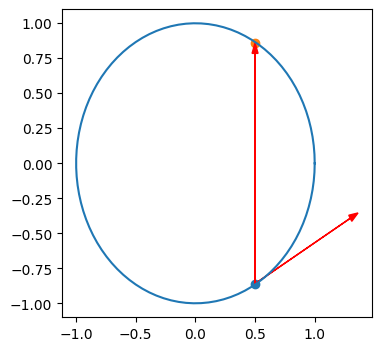

In [5]:
t = np.linspace(0,2*np.pi,100)

x = np.cos(t)
y = np.sin(t)

x1 = 0.5
y1 = -0.86
x2 = 0.5
y2 = 0.86

a = np.array([x1,y1])
b = np.array([x2,y2])
a_hat = a / np.linalg.norm(a)
rej = b - np.dot(a,b)*a_hat # Rejection vector
rej = rej/np.linalg.norm(rej)
plt.figure(figsize=(4,4))
plt.plot(x,y)
plt.scatter(x1,y1)
plt.scatter(x2,y2)
plt.arrow(x1, y1, x2 - x1, y2 - y1,head_width=0.05, length_includes_head=True, color='red')
plt.arrow(x1, y1, rej[0], rej[1],head_width=0.05, length_includes_head=True, color='red')


# Corresponding 3D 

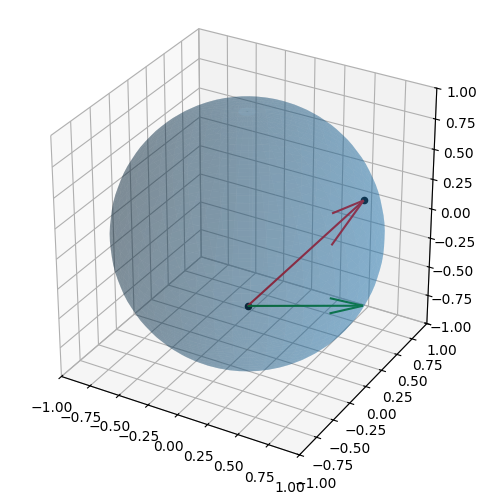

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

theta = np.linspace(0, 2*np.pi, 50)
phi = np.linspace(0, np.pi, 50)

theta, phi = np.meshgrid(theta, phi)

x = np.sin(phi) * np.cos(theta)
y = np.sin(phi) * np.sin(theta)
z = np.cos(phi)

x1, y1, z1 = 0.5, -0.86, 0
x2, y2, z2 = 0.5,  0.86, 0

a = np.array([x1, y1, z1])
b = np.array([x2, y2, z2])

# Unit vector
a_hat = a / np.linalg.norm(a)

rej = b - np.dot(a_hat, b) * a_hat

# plot
fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111, projection='3d')

# sphere
ax.plot_surface(x, y, z, alpha=0.3)

# points
ax.scatter(x1, y1, z1)
ax.scatter(x2, y2, z2)

# vector from a to b
ax.quiver(x1, y1, z1,
          x2 - x1, y2 - y1, z2 - z1)

# rejection vector
ax.quiver(x1, y1, z1,
          rej[0], rej[1], rej[2])

# formatting
ax.set_box_aspect([1,1,1])
ax.set_xlim([-1,1])
ax.set_ylim([-1,1])
ax.set_zlim([-1,1])

plt.show()

# Method using rotation vector

In [26]:
def rotation_basis(lat,lon):
    north_basis = np.array([-np.sin(lat)*np.cos(lon),-np.sin(lat)*np.sin(lon),np.cos(lat)])
    east_basis = np.array([-np.sin(lon), np.cos(lon), 0.0])
    up_basis = np.array([
                np.cos(lat) * np.cos(lon),
                np.cos(lat) * np.sin(lon),
                np.sin(lat)
            ])

    basis = np.vstack((north_basis, east_basis, up_basis))
    return basis

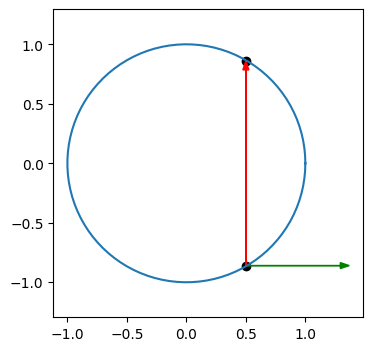

In [37]:
# unit circle
t = np.linspace(0, 2*np.pi, 100)
x = np.cos(t)
y = np.sin(t)

# points on the unit circle
x1, y1 = 0.5, -0.86
x2, y2 = 0.5,  0.86

a = np.array([x1, y1, 0.0])
b = np.array([x2, y2, 0.0])


a = a / np.linalg.norm(a)
b = b / np.linalg.norm(b)

# Cartesian difference
vdiff_cart = b - a

# lat/lon of point a
lon = np.arctan2(a[1], a[0])
lat = np.arcsin(a[2]) 

# local North-East-Up basis at a
R = rotation_basis(lat, lon)

# vector components in local rotated coordinates
vdiff_local = R @ vdiff_cart
north, east, up = vdiff_local

plt.figure(figsize=(4, 4))
plt.plot(x, y)
plt.scatter(x1, y1, color='black')
plt.scatter(x2, y2, color='black')

plt.arrow(x1, y1, x2 - x1, y2 - y1,
          head_width=0.05, length_includes_head=True, color='red')

plt.arrow(x1, y1, east, north,
          head_width=0.05, length_includes_head=True, color='green')

plt.axis('equal')
plt.show()

# 3D

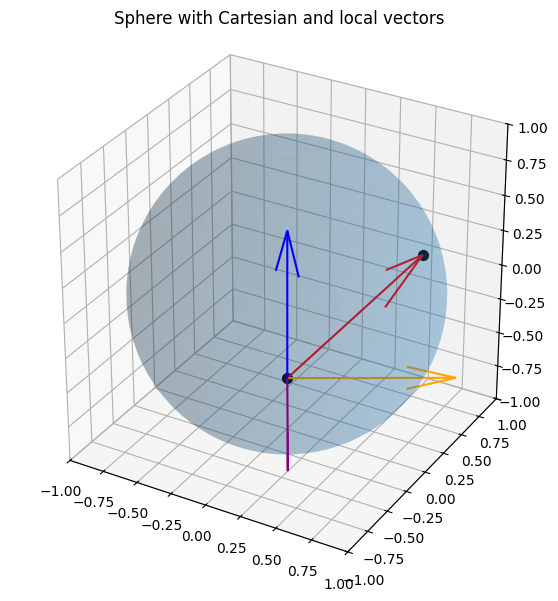

a = [ 0.50262046 -0.86450719  0.        ]
b = [0.50262046 0.86450719 0.        ]
vdiff_cart = [0.         1.72901437 0.        ]
vdiff_local [north, east, up] = [ 0.          0.869038   -1.49474535]


In [35]:

# points on the unit sphere
x1, y1, z1 = 0.5, -0.86, 0.0
x2, y2, z2 = 0.5,  0.86, 0.0

a = np.array([x1, y1, z1], dtype=float)
b = np.array([x2, y2, z2], dtype=float)

a = a / np.linalg.norm(a)
b = b / np.linalg.norm(b)

# Cartesian difference
vdiff_cart = b - a

# lat/lon of point a
lon = np.arctan2(a[1], a[0])
lat = np.arcsin(a[2])

# local North-East-Up basis at a
R = rotation_basis(lat, lon)

# vector components in local coordinates
vdiff_local = R @ vdiff_cart
north, east, up = vdiff_local

# sphere surface
u = np.linspace(0, 2*np.pi, 100)
v = np.linspace(0, np.pi, 50)
U, V = np.meshgrid(u, v)

X = np.cos(U) * np.sin(V)
Y = np.sin(U) * np.sin(V)
Z = np.cos(V)

fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection='3d')

# sphere
ax.plot_surface(X, Y, Z, alpha=0.2)

# points
ax.scatter(*a, color='black', s=50)
ax.scatter(*b, color='black', s=50)

# Cartesian directional vector
ax.quiver(a[0], a[1], a[2],
          vdiff_cart[0], vdiff_cart[1], vdiff_cart[2],
          color='red')

north_basis, east_basis, up_basis = R[0], R[1], R[2]
ax.quiver(a[0], a[1], a[2],
          north_basis[0], north_basis[1], north_basis[2],
          color='blue')
ax.quiver(a[0], a[1], a[2],
          east_basis[0], east_basis[1], east_basis[2],
          color='orange')
ax.quiver(a[0], a[1], a[2],
          up_basis[0], up_basis[1], up_basis[2],
          color='purple')

ax.set_box_aspect([1, 1, 1])
ax.set_xlim([-1, 1])
ax.set_ylim([-1, 1])
ax.set_zlim([-1, 1])
ax.set_title("Sphere with Cartesian and local vectors")

plt.show()

print("a =", a)
print("b =", b)
print("vdiff_cart =", vdiff_cart)
print("vdiff_local [north, east, up] =", vdiff_local)